In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("russia_losses_equipment.csv", 
                 parse_dates=["date"], 
                 index_col="date")

In [3]:
df.head()

,day,aircraft,helicopter,tank,APC,field artillery,MRL,military auto,fuel tank,drone,naval ship,anti-aircraft warfare,special equipment,mobile SRBM system,greatest losses direction,vehicles and fuel tanks,cruise missiles,submarines
date,,,,,,,,,,,,,,,,,,
2026-03-15,1481,435,349,11781,24213,38438,1686,NaN,NaN,179270,32,1332,4089.0,NaN,NaN,83513.0,4468.0,2.0
2026-03-14,1480,435,349,11777,24212,38421,1686,NaN,NaN,177286,31,1332,4088.0,NaN,NaN,83403.0,4403.0,2.0
2026-03-13,1479,435,349,11773,24202,38369,1685,NaN,NaN,175139,31,1331,4088.0,NaN,NaN,83223.0,4403.0,2.0
2026-03-12,1478,435,349,11766,24197,38319,1681,NaN,NaN,173068,31,1329,4088.0,NaN,NaN,83034.0,4403.0,2.0
2026-03-11,1477,435,349,11763,24177,38263,1680,NaN,NaN,170966,31,1328,4088.0,NaN,NaN,82791.0,4403.0,2.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1480 entries, 2026-03-15 to 2022-02-25
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   day                        1480 non-null   int64  
 1   aircraft                   1480 non-null   int64  
 2   helicopter                 1480 non-null   int64  
 3   tank                       1480 non-null   int64  
 4   APC                        1480 non-null   int64  
 5   field artillery            1480 non-null   int64  
 6   MRL                        1480 non-null   int64  
 7   military auto              65 non-null     float64
 8   fuel tank                  65 non-null     float64
 9   drone                      1480 non-null   int64  
 10  naval ship                 1480 non-null   int64  
 11  anti-aircraft warfare      1480 non-null   int64  
 12  special equipment          1461 non-null   float64
 13  mobile SRBM system         36 

In [6]:
df.describe()

,day,aircraft,helicopter,tank,APC,field artillery,MRL,military auto,fuel tank,drone,naval ship,anti-aircraft warfare,special equipment,mobile SRBM system,vehicles and fuel tanks,cruise missiles,submarines
count,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,65.000000,65.000000,1480.000000,1480.000000,1480.000000,1461.000000,36.000000,1415.000000,1415.000000,914.000000
mean,741.500000,330.687838,296.962162,6626.651351,13410.203378,14108.988514,924.581081,1047.507692,69.323077,22780.202703,22.293243,691.001351,1982.986995,3.944444,25475.479152,2076.098233,1.098468
std,427.383512,76.719574,61.556814,3619.227271,7485.916220,12311.872909,468.749103,466.162060,7.545917,33258.550451,6.473681,422.221409,1599.996521,0.333333,23683.254614,1270.605738,0.298110
min,2.000000,10.000000,7.000000,80.000000,516.000000,49.000000,4.000000,100.000000,60.000000,0.000000,2.000000,0.000000,10.000000,2.000000,1796.000000,84.000000,1.000000
25%,371.750000,300.000000,288.000000,3396.500000,6653.000000,2396.750000,479.750000,600.000000,60.000000,2057.250000,18.000000,247.000000,257.000000,4.000000,5699.500000,911.000000,1.000000
50%,741.500000,347.000000,325.000000,6667.500000,12708.000000,10283.000000,1007.500000,1178.000000,73.000000,7892.000000,25.500000,700.500000,1711.000000,4.000000,15071.000000,2064.000000,1.000000
75%,1111.250000,370.000000,331.000000,10294.750000,21405.750000,24289.750000,1311.500000,1437.000000,76.000000,28652.500000,28.000000,1102.250000,3777.000000,4.000000,41985.500000,3121.000000,1.000000
max,1481.000000,435.000000,349.000000,11781.000000,24213.000000,38438.000000,1686.000000,1701.000000,76.000000,179270.000000,32.000000,1332.000000,4089.000000,4.000000,83513.000000,4468.000000,2.000000


In [8]:
df1 = df[["APC"]]

In [10]:
df1.isnull().sum()

APC    0
dtype: int64

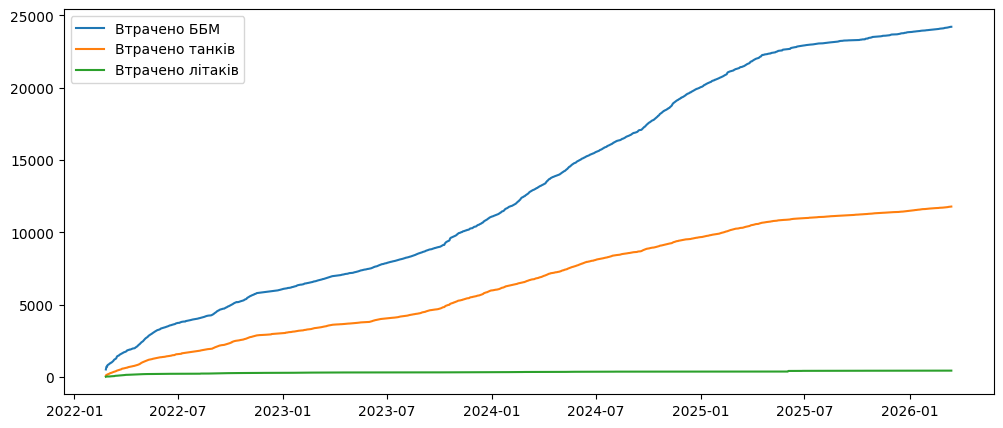

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df1["APC"], label = "Втрачено ББМ")
plt.plot(df["tank"], label = "Втрачено танків")
plt.plot(df["aircraft"], label = "Втрачено літаків")
plt.legend()
plt.show()

In [12]:
from statsmodels.tsa.arima.model import ARIMA

In [13]:
train_size = int(len(df1)*0.9)
train_size


1332

In [14]:
df1 = df1.iloc[::-1]

In [29]:
df1.head()

,APC
date,
2022-02-25,516
2022-02-26,706
2022-02-27,706
2022-02-28,816
2022-03-01,846


In [17]:
train,test = df1[:train_size], df1[train_size:] 

In [18]:
model = ARIMA(train["APC"], order=(5,1,0))

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [19]:
model_fit = model.fit()

In [20]:
forecast = model_fit.forecast(steps=len(test))
test["forecast"] = forecast


C:\Users\User\AppData\Local\Temp\ipykernel_17400\277756396.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["forecast"] = forecast


In [28]:
test.head()

,APC,forecast
date,,
2025-10-19,23399,23403.431240
2025-10-20,23399,23412.813065
2025-10-21,23436,23426.323585
2025-10-22,23447,23435.069752
2025-10-23,23453,23443.021224


In [23]:

print(forecast)

2025-10-19    23403.431240
2025-10-20    23412.813065
2025-10-21    23426.323585
2025-10-22    23435.069752
2025-10-23    23443.021224
                  ...     
2026-03-11    23937.296163
2026-03-12    23938.217086
2026-03-13    23939.123077
2026-03-14    23940.014378
2026-03-15    23940.891227
Freq: D, Name: predicted_mean, Length: 148, dtype: float64


In [30]:
test.head()

,APC,forecast
date,,
2025-10-19,23399,23403.431240
2025-10-20,23399,23412.813065
2025-10-21,23436,23426.323585
2025-10-22,23447,23435.069752
2025-10-23,23453,23443.021224


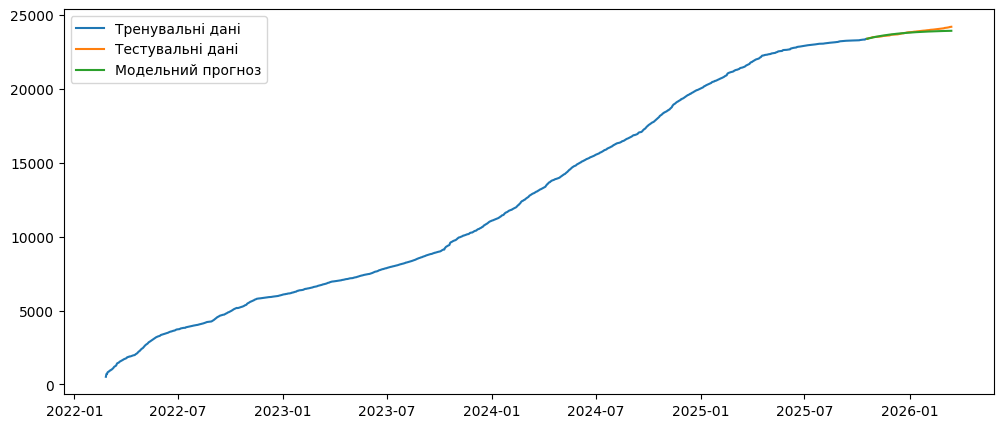

In [26]:
plt.figure(figsize=(12,5))
plt.plot(train["APC"], label = "Тренувальні дані")
plt.plot(test["APC"], label = "Тестувальні дані")
plt.plot(test["forecast"], label = "Модельний прогноз")
plt.legend()
plt.show()